In [130]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression


In [47]:
df = pd.read_csv("C:/Users/user/Documents/EBAC/dados/marketing_campaign.csv", delimiter=';')

df.head(10)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
5,1967,Master,Together,62513.0,0,16,520,42,98,0,42,14,10,6,0,1
6,1971,Graduation,Divorced,55635.0,0,34,235,65,164,50,49,27,7,6,0,1
7,1985,PhD,Married,33454.0,1,32,76,10,56,3,1,23,4,8,0,1
8,1974,PhD,Together,30351.0,1,19,14,0,24,3,3,2,2,9,0,0
9,1950,PhD,Together,5648.0,1,68,28,0,6,1,1,13,0,20,0,0


In [48]:
# Preparação de dados

In [49]:
df.isnull().values.any() #Indica que existe(m) valor(es) nulo(s) no dataframe

True

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13)

In [51]:
df.isnull().sum() # numero de valores nulos por coluna

Year_Birth            0
Education             0
Marital_Status        0
Income               24
Kidhome               0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumStorePurchases     0
NumWebVisitsMonth     0
Complain              0
WebPurchases          0
dtype: int64

In [52]:
# Excluindo valores nulos (Income)

df.dropna(subset=['Income'], inplace=True)

In [53]:
df.isnull().values.any() 

False

In [54]:
df['Marital_Status'].unique() # Verificando formas 'unicas' que podem ter sido inseridas na variável Marital_Status

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [55]:
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,1968.820397,52247.251354,0.441787,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,5.800993,5.319043,0.009477,0.504513
std,11.985554,25173.076661,0.536896,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,3.250785,2.425359,0.096907,0.500092
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,13.000000,20.000000,1.000000,1.000000


TypeError: Legend.__init__() got an unexpected keyword argument 'lavels'

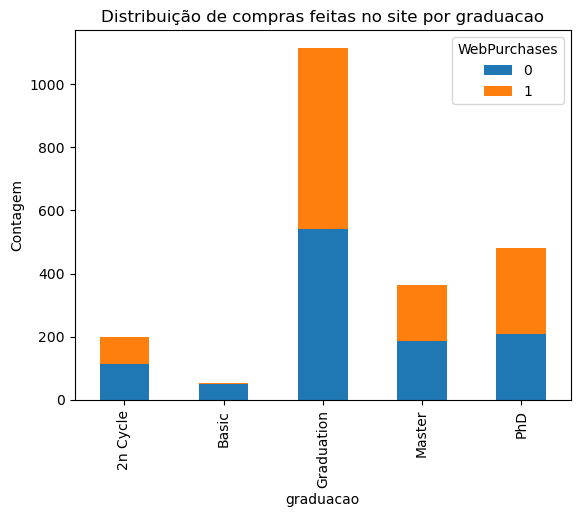

In [56]:
# breve analise bivariada para conhecermos melhor nossos dados 
contagem = pd.crosstab(df['Education'], df['WebPurchases'])
contagem.plot(kind='bar', stacked=True)
plt.title('Distribuição de compras feitas no site por graduacao')
plt.xlabel('graduacao')
plt.ylabel('Contagem')
plt.legend(title='webPurchases', lavels=['1', '0'])
plt.show()

In [ ]:
contagem = pd.crosstab(df['Marital_Status'], df['WebPurchases'])
contagem.plot(kind='bar', stacked=True)
plt.title('Distribuição de compras feitas no site por status matrimonial')
plt.xlabel('matrimonio')
plt.ylabel('Contagem')
plt.legend(title='webPurchases', lavels=['1', '0'])
plt.show()

In [ ]:
contagem = pd.crosstab(df['Kidhome'], df['WebPurchases'])
contagem.plot(kind='bar', stacked=True)
plt.title('Distribuição de compras feitas no site por pessoas com filhos em casa')
plt.xlabel('familias')
plt.ylabel('Contagem')
plt.legend(title='webPurchases', lavels=['1', '0'])
plt.show()

TypeError: Legend.__init__() got an unexpected keyword argument 'lavels'

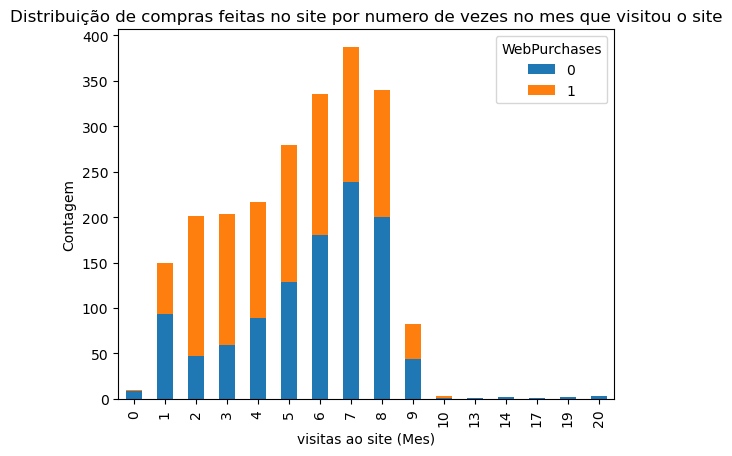

In [57]:
contagem = pd.crosstab(df['NumWebVisitsMonth'], df['WebPurchases'])
contagem.plot(kind='bar', stacked=True)
plt.title('Distribuição de compras feitas no site por numero de vezes no mes que visitou o site')
plt.xlabel('visitas ao site (Mes)')
plt.ylabel('Contagem')
plt.legend(title='webPurchases', lavels=['1', '0'])
plt.show()

In [ ]:
# Observamos que o maior numero de compras no site, percentualmente falando, ocorre em maioria dentre os que possuem ao menos a graduacao,
# tendo em vista que este perfil possui mais facilidade para utilizar da internet e também possui uma vida mais dedicada ao trabalho e com menos tempo 
# para realizar estas tarefas de maneira presencial 

# assim como notamos um certo equilibrio de compras online nas categorias de casado, solteiro e em relacionamento, demonstrando o mesmo perfil de pessoas
# que estao na fase adulta e no mercado de trabalho 

# o terceiro grafico, que é em relacao ao numero de filhos, tambem nos da o entendimento de se tratar do mesmo grupo de pessoas citados anteriormente, pois
# o grafico de 0 filhos demonstra que a maioria realiza as compras online e no grafico com 1 filho ja tende a ser menos vezes desta maneira 

# e notamos que o numero de clientes que visita o site demonstra alto indice de procura por novidades e satisfacao com o produto, pois o numero de visitas
# reflete tambem altos indices de compras, porem, nitidamente os clientes interessados em comprar, comecam a visitar menos o site apartir da 7ª visita

In [ ]:
# Pré-processamento

In [58]:
education_mapping = {
    'Basic': 0,
    'Graduation': 1,
    '2n Cycle': 2,  # Ajuste este valor conforme o significado de '2n Cycle'
    'Master': 3,
    'PhD': 4
}

# Aplique o mapeamento à coluna 'Education'
df['Education_Encoded'] = df['Education'].map(education_mapping)

# Exiba o DataFrame com a nova coluna codificada
print(df[['Education', 'Education_Encoded']].head())

    Education  Education_Encoded
0  Graduation                  1
1  Graduation                  1
2  Graduation                  1
3  Graduation                  1
4         PhD                  4


In [62]:
X = df.drop(columns=['Marital_Status', 'Education'])

In [63]:
X.head(10)

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases,Education_Encoded
0,1957,58138.0,0,58,635,88,546,172,88,88,4,7,0,1,1
1,1954,46344.0,1,38,11,1,6,2,1,6,2,5,0,0,1
2,1965,71613.0,0,26,426,49,127,111,21,42,10,4,0,1,1
3,1984,26646.0,1,26,11,4,20,10,3,5,4,6,0,0,1
4,1981,58293.0,1,94,173,43,118,46,27,15,6,5,0,1,4
5,1967,62513.0,0,16,520,42,98,0,42,14,10,6,0,1,3
6,1971,55635.0,0,34,235,65,164,50,49,27,7,6,0,1,1
7,1985,33454.0,1,32,76,10,56,3,1,23,4,8,0,1,4
8,1974,30351.0,1,19,14,0,24,3,3,2,2,9,0,0,4
9,1950,5648.0,1,68,28,0,6,1,1,13,0,20,0,0,4


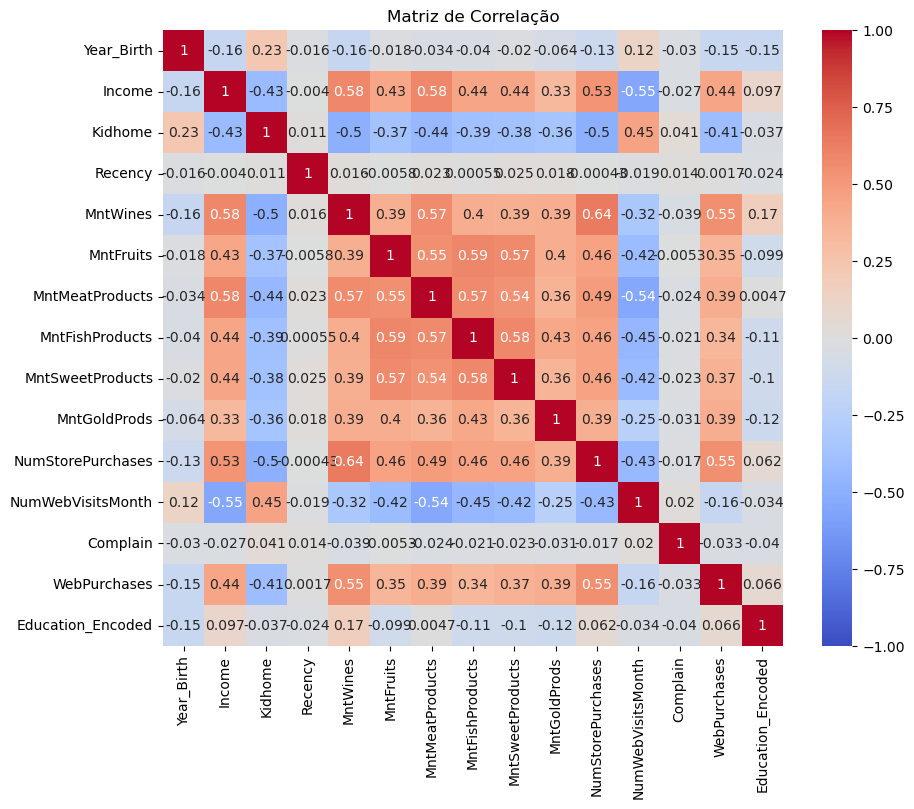

In [66]:
correlation_matrix = X.corr()

# plotando a matriz de correlação usando seaborn
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

In [68]:
colunas_selecionadas = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumStorePurchases', 'WebPurchases']

# Cria um novo DataFrame contendo apenas as colunas selecionadas
df_corr = df[colunas_selecionadas].copy()

df_corr.head(10)

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,WebPurchases
0,58138.0,635,88,546,172,88,88,4,1
1,46344.0,11,1,6,2,1,6,2,0
2,71613.0,426,49,127,111,21,42,10,1
3,26646.0,11,4,20,10,3,5,4,0
4,58293.0,173,43,118,46,27,15,6,1
5,62513.0,520,42,98,0,42,14,10,1
6,55635.0,235,65,164,50,49,27,7,1
7,33454.0,76,10,56,3,1,23,4,1
8,30351.0,14,0,24,3,3,2,2,0
9,5648.0,28,0,6,1,1,13,0,0


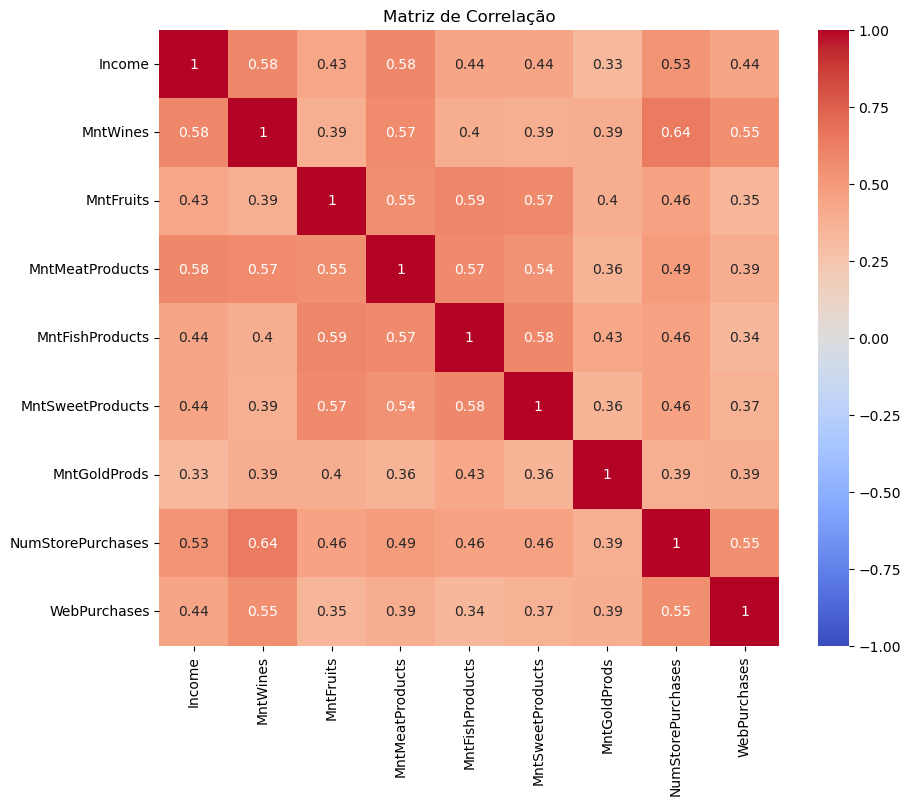

In [70]:
correlation_matrix = df_corr.corr()

# plotando a matriz de correlação usando seaborn
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

In [73]:
df_padronizado = df_corr.copy()

In [76]:
colunas_padronizar = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumStorePurchases']

# Iniciar o StandardScaler
scaler = StandardScaler()

# Ajustar e transformar os dados selecionados
df_padronizado[colunas_padronizar] = scaler.fit_transform(df[colunas_padronizar])

In [77]:
# Separando em X (Variáveis de entrada) e Y (Variável de saída)

X = df_padronizado.drop('WebPurchases', axis=1) # X contém todas as colunas, exceto 'WebPurchases'
Y = df_padronizado['WebPurchases'] # Y contém apenas a coluna 'WebPurchases'

In [78]:
# Modelagem 

In [80]:
pca = PCA(n_components= 5 ) # Substitua pelo número de componentes que deseja
# Ajustando o PCA aos dados X
pca.fit(X)

PCA(n_components=5)

In [81]:
# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()

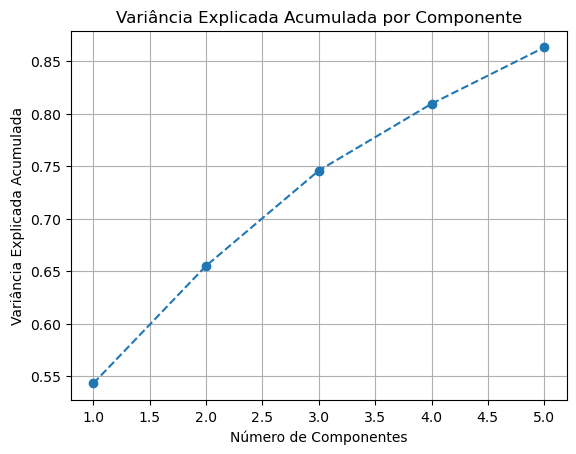

In [85]:
# Plotando a variância explicada acumulada
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()

In [86]:
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.54314985 0.11194153 0.09070366 0.06357144 0.0537038 ]
[98.12726742 44.54772082 40.09980591 33.57073826 30.85548484]


In [87]:
X_pca = pca.fit_transform(X)

In [88]:
X_pca

array([[ 3.10382356, -1.78723443, -0.29216822, -0.84060694, -0.3643911 ],
       [-1.99234715, -0.14672325, -0.3415065 , -0.47636939,  0.14803498],
       [ 1.42963538,  0.21986051, -0.11784772,  0.62736529, -0.51857011],
       ...,
       [ 1.5042458 ,  1.81131352, -0.12668706,  1.51845565, -0.94350719],
       [ 1.35158301,  0.48831664,  0.15440906,  0.41460937, -0.06800589],
       [-1.40630513,  0.2303339 , -0.14782134, -0.33921986,  0.11093968]])

In [89]:
Y

0       1
1       0
2       1
3       0
4       1
       ..
2235    1
2236    1
2237    0
2238    1
2239    0
Name: WebPurchases, Length: 2216, dtype: int64

In [90]:
X_train, X_test, Y_train, Y_test = train_test_split(X_pca, Y, test_size=0.3, random_state=42)

In [92]:
rf_model = RandomForestClassifier(random_state=42)

In [93]:
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [94]:
Y_pred = rf_model.predict(X_test)

In [95]:
print("Matriz de Confusão:")
print(confusion_matrix(Y_test, Y_pred))

print("\nRelatório de Classificação:")
print(classification_report(Y_test, Y_pred))

Matriz de Confusão:
[[270  68]
 [ 19 308]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86       338
           1       0.82      0.94      0.88       327

    accuracy                           0.87       665
   macro avg       0.88      0.87      0.87       665
weighted avg       0.88      0.87      0.87       665



In [131]:
# Inicializar StandardScaler
sc = StandardScaler()

# Ajustando e transformando os dados de treino
X_train = sc.fit_transform(X_train)

# Transformando os dados de teste usando os parâmetros aprendidos dos dados de treino
X_test = sc.transform(X_test)

In [132]:
# Iniciando treinamento

logistic_cardio = LogisticRegression(random_state = 0)
# poderiamos adicionar max_iter = um valoar. Ele controla o número máximo de vezes que o algoritmo itera sobre o conjunto de dados para encontrar 
# os melhores coeficientes

In [133]:
# Balanceando os dados de treinamento usando SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

In [134]:
logistic_cardio.fit(X_train_balanced, Y_train_balanced)

LogisticRegression(random_state=0)

In [135]:
previsoes = logistic_cardio.predict(X_train_balanced)

In [137]:
print("Matriz de Confusão:")
print(confusion_matrix(Y_train_balanced, previsoes))

relatorio = classification_report(Y_train_balanced, previsoes)
print('Relatório de Classificação:')
print(relatorio)

Matriz de Confusão:
[[661 130]
 [168 623]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       791
           1       0.83      0.79      0.81       791

    accuracy                           0.81      1582
   macro avg       0.81      0.81      0.81      1582
weighted avg       0.81      0.81      0.81      1582



In [ ]:
# Random forest x regressao logistica

# O random forest apresentou melhor precisao para a classe 0 (93% x 83%)

# O random forest apresentou recall (que sao as instancias corretamente identificadas) superior na classe 1 (94% x 79%)

# O f1-score doi superior no random forest em media de 5 pontos percentuais em ambas as classes 

# A acurácia tambem foi superior no random forest (87% x 81%)

# Conseguentemente, os valores das medias ponderadas tambem foi superior no random forest

In [ ]:
# Matriz de confusao
# random forest

# O modelo classificou corretamente 270 amostras como pertencentes à classe negativa.

# O modelo classificou corretamente 308 amostras como pertencentes à classe positiva.

# O modelo errou ao classificar 68 amostras negativas como positivas.

# O modelo errou ao classificar 19 amostras positivas como negativas.

# regressao

# O modelo classificou corretamente 661 amostras como pertencentes à classe negativa.

# O modelo classificou corretamente 623 amostras como pertencentes à classe positiva.

# O modelo errou ao classificar 130 amostras negativas como positivas.

# O modelo errou ao classificar 168 amostras positivas como negativas.


In [ ]:
# Com base nos relatorios, podemos afirmar que 